In [18]:
# https://github.com/HinLeung622/pipes_vis/blob/main/pipes_vis_example.ipynb
import pipes_vis as v
import numpy as np
import pandas as pd

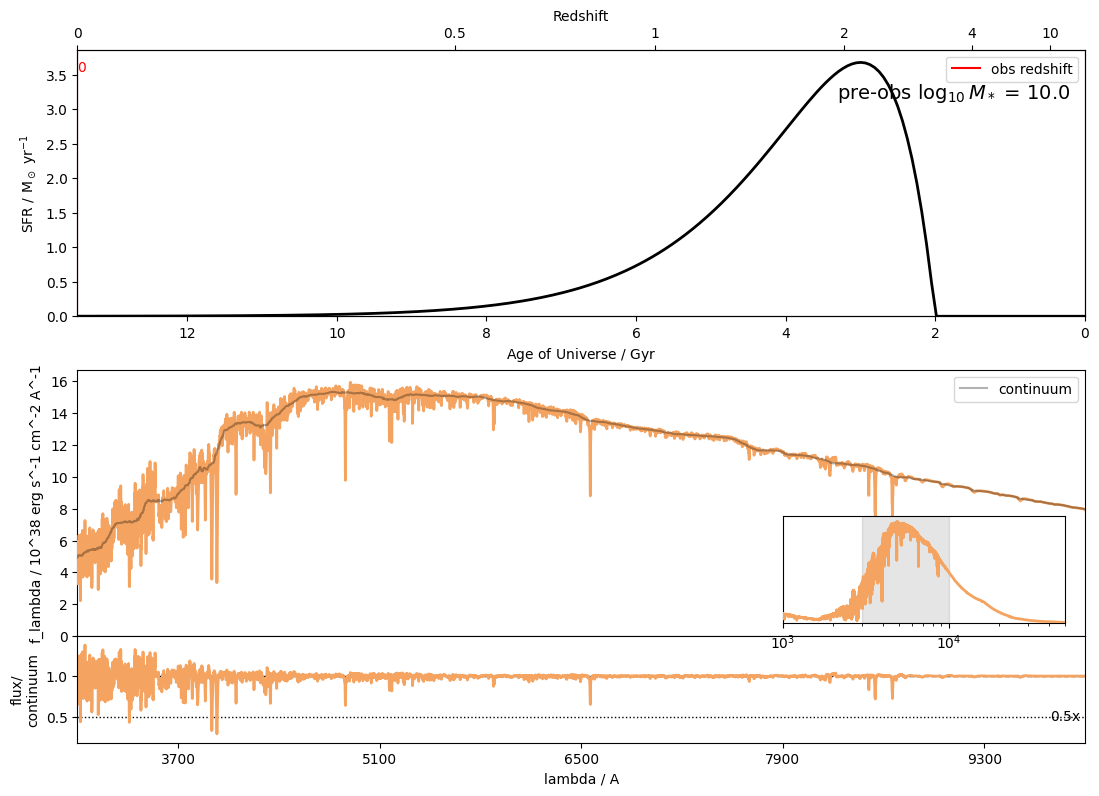

In [19]:
delayed = {}
delayed["massformed"] = 10.0                 # total log_10(M*/M_sun) of the galaxy, for the whole SFH
delayed["metallicity"] = 0.1                 # assumed constant metallicity, in number of times of Z_sun
delayed["tform"] = 2                        # age of universe when the population formed, Gyr
delayed["tau"] = 1                          # SFR decay timescale of the population, Gyr

dust = {}                                    # dust attenuation and emission, implementation identical to bagpipes
dust["type"] = "CF00"                        # Charlot & Fall (2001)
dust["eta"] = 2.0                            # additional scaling factor for dust in birth clouds (1/mu)
dust["Av"] = 0                               # extinction in V band (5500AA)
dust["n"] = 0.7                              # slope of the attenuation law


init_components = {}

init_components["redshift"] = 0          # redshift at observation
init_components["delayed"] = delayed
init_components["spec_lim"] = [3000,10000]   # wavelength boundaries of the main spectrum panel
init_components["dust"] = dust

simple_vis = v.visualizer(init_components)
simple_vis.static_plot()
spectrum=simple_vis.model.spectrum

(3000.0, 10000.0)

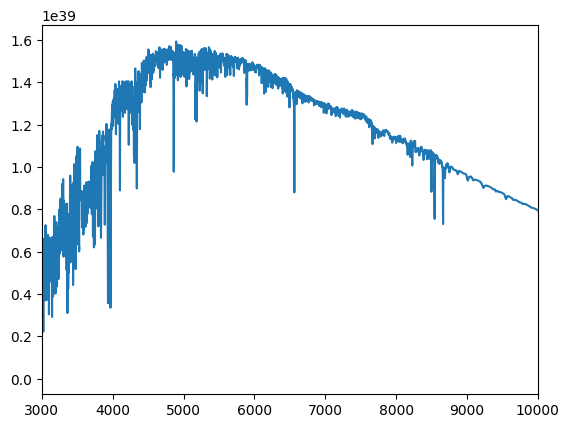

In [20]:
import matplotlib.pyplot as plt
plt.plot(spectrum[:,0],spectrum[:,1])
plt.xlim(3000,10000)

## Automatic Monte Carlo search for SED degeneracies

The GUI plot above is kept as the baseline visualisation. The cells below do not generate a plot for every trial. They compute spectra numerically, compare them to the baseline, and plot only the best degenerate solution at the end.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random
import bagpipes as pipes


In [22]:
# Baseline parameters from the problem statement / GUI cell above.
baseline_params = {
    "massformed": 10.0,
    "metallicity": 0.1,
    "tform": 2.0,
    "tau": 1.0,
    "Av": 0.0,
    "n": 0.7,
    "eta": 2.0,
    "redshift": 0.0
}

# For direct BAGPIPES calls, the delayed SFH uses 'age', not 'tform'.
# In pipes_vis, tform is the age of the Universe when the population formed.
# At z=0, age_of_universe - tform gives the stellar population age.
AGE_OF_UNIVERSE_GYR = 13.8


In [23]:
def tform_to_age(tform, redshift=0.0):
    """Convert pipes_vis tform into BAGPIPES delayed-SFH age.
    """
    return AGE_OF_UNIVERSE_GYR - tform


def make_sed_fast(massformed=10.0, metallicity=0.1, tform=2.0, tau=1.0,
                  Av=0.0, n=0.7, eta=2.0, redshift=0.0,
                  wav_min=3000.0, wav_max=10000.0, wav_step=20.0):
    """Generate a BAGPIPES model spectrum without opening the pipes_vis GUI.
    """
    age = tform_to_age(tform, redshift=redshift)

    components = {
        "redshift": redshift,
        "delayed": {
            "massformed": massformed,
            "metallicity": metallicity,
            "age": age,
            "tau": tau
        },
        "dust": {
            "type": "CF00",
            "eta": eta,
            "Av": Av,
            "n": n
        }
    }

    wavs = np.arange(wav_min, wav_max, wav_step)
    model = pipes.model_galaxy(components, spec_wavs=wavs)
    return model.spectrum


In [24]:
def normalise_sed(sed):
    wave = sed[:, 0]
    flux = sed[:, 1]
    flux_norm = flux / np.nanmedian(flux)
    return wave, flux_norm


def sed_distance(sed1, sed2, wave_min=3000, wave_max=10000):
    """Mean squared difference between median-normalised spectra."""
    w1, f1 = normalise_sed(sed1)
    w2, f2 = normalise_sed(sed2)

    f2_interp = np.interp(w1, w2, f2)
    mask = (w1 >= wave_min) & (w1 <= wave_max)
    diff = f1[mask] - f2_interp[mask]

    chi2_like = np.nanmean(diff**2)
    max_abs_diff = np.nanmax(np.abs(diff))
    return chi2_like, max_abs_diff


In [25]:
# Compute the baseline numerically once.
baseline_sed = make_sed_fast(**baseline_params)

print("baseline_sed shape:", baseline_sed.shape)
print(baseline_sed[:3])


baseline_sed shape: (350, 2)
[[3.00000000e+03 4.59971115e+38]
 [3.02000000e+03 4.73264913e+38]
 [3.04000000e+03 5.06334767e+38]]


## Monte Carlo parameter search

In [26]:
# Reproducible random search.
random.seed(7)
np.random.seed(7)

N_MODELS = 60  


def random_params():
    return {
        "massformed": 10.0,
        "metallicity": float(10 ** np.random.uniform(np.log10(0.03), np.log10(0.4))),
        "tform": float(np.random.uniform(0.8, 4.0)),
        "tau": float(10 ** np.random.uniform(np.log10(0.3), np.log10(3.0))),
        "Av": float(np.random.uniform(0.0, 0.35)),
        "n": float(np.random.choice([0.5, 0.7, 0.9])),
        "eta": 2.0,
        "redshift": 0.0
    }


results = []
best_score = np.inf
best_sed = None

for i in tqdm(range(N_MODELS)):
    params = random_params()
    if (
        np.isclose(params["metallicity"], baseline_params["metallicity"])
        and np.isclose(params["tform"], baseline_params["tform"])
        and np.isclose(params["tau"], baseline_params["tau"])
        and np.isclose(params["Av"], baseline_params["Av"])
    ):
        continue

    try:
        sed = make_sed_fast(**params)
        chi2_like, max_abs_diff = sed_distance(baseline_sed, sed)

        results.append({
            **params,
            "chi2_like": chi2_like,
            "max_abs_diff": max_abs_diff
        })

        if chi2_like < best_score:
            best_score = chi2_like
            best_sed = sed
            print("New best:", {k: round(v, 4) if isinstance(v, float) else v for k, v in params.items()}, "score =", chi2_like)

    except Exception as e:
        print("Failed:", params, e)

results_df = pd.DataFrame(results)

if len(results_df) == 0:
    raise RuntimeError("No successful models. Check the error messages above.")

results_df = results_df.sort_values("chi2_like").reset_index(drop=True)
display(results_df.head(10))


  0%|          | 0/60 [00:00<?, ?it/s]

New best: {'massformed': 10.0, 'metallicity': 0.0366, 'tform': 3.2957, 'tau': 0.8232, 'Av': 0.2532, 'n': 0.5, 'eta': 2.0, 'redshift': 0.0} score = 0.00029995725491937267
New best: {'massformed': 10.0, 'metallicity': 0.0666, 'tform': 1.6444, 'tau': 0.3663, 'Av': 0.1468, 'n': 0.5, 'eta': 2.0, 'redshift': 0.0} score = 8.938561035298297e-05
New best: {'massformed': 10.0, 'metallicity': 0.0851, 'tform': 2.9838, 'tau': 0.9529, 'Av': 0.139, 'n': 0.5, 'eta': 2.0, 'redshift': 0.0} score = 2.9835952128975897e-05


,massformed,metallicity,tform,tau,Av,n,eta,redshift,chi2_like,max_abs_diff
0,10.0,0.085071,2.983846,0.952894,0.139012,0.5,2.0,0.0,0.000030,0.020380
1,10.0,0.066622,1.644387,0.366323,0.146780,0.5,2.0,0.0,0.000089,0.024757
2,10.0,0.049503,1.121517,0.911503,0.214796,0.5,2.0,0.0,0.000102,0.047336
3,10.0,0.054493,2.909307,0.407001,0.078428,0.9,2.0,0.0,0.000115,0.054611
4,10.0,0.073016,3.056225,0.870980,0.135377,0.9,2.0,0.0,0.000140,0.030288
5,10.0,0.090837,2.719534,1.604289,0.287430,0.7,2.0,0.0,0.000251,0.081368
6,10.0,0.036556,3.295740,0.823248,0.253213,0.5,2.0,0.0,0.000300,0.092171
7,10.0,0.120881,2.437663,0.523971,0.002162,0.9,2.0,0.0,0.000370,0.055158
8,10.0,0.178750,2.634970,1.767012,0.137567,0.5,2.0,0.0,0.000403,0.088007
9,10.0,0.081515,1.545890,0.449677,0.139477,0.7,2.0,0.0,0.000438,0.038695


## Plot the best degenerate SED

Only the final best model is plotted against the baseline. 


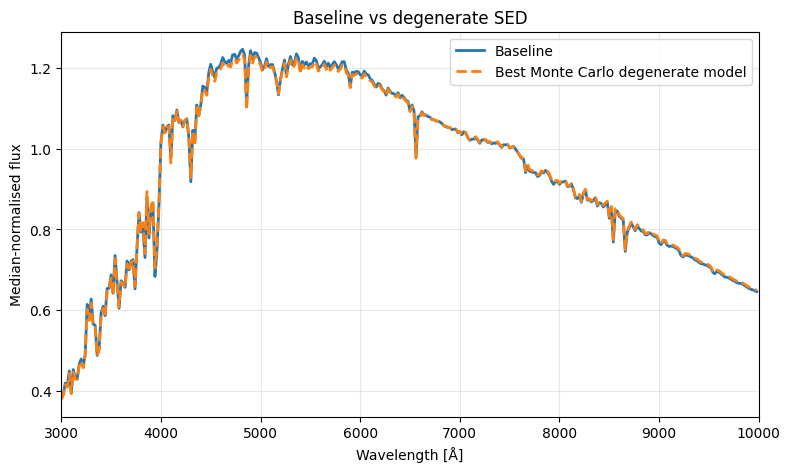

Best degenerate parameters:
massformed: 10.0
metallicity: 0.08507141330729395
tform: 2.983846243465818
tau: 0.9528943320860891
Av: 0.13901223357876102
n: 0.5
eta: 2.0
redshift: 0.0
chi2_like: 2.9835952128975897e-05
max_abs_diff: 0.02038037505801049


In [27]:
best = results_df.iloc[0].to_dict()

# Recompute best SED once for plotting.
best_sed = make_sed_fast(
    massformed=best["massformed"],
    metallicity=best["metallicity"],
    tform=best["tform"],
    tau=best["tau"],
    Av=best["Av"],
    n=best["n"],
    eta=best["eta"],
    redshift=best["redshift"]
)

w_base, f_base = normalise_sed(baseline_sed)
w_best, f_best = normalise_sed(best_sed)

plt.figure(figsize=(9, 5))
plt.plot(w_base, f_base, label="Baseline", linewidth=2)
plt.plot(w_best, f_best, "--", label="Best Monte Carlo degenerate model", linewidth=2)

plt.xlabel("Wavelength [Å]")
plt.ylabel("Median-normalised flux")
plt.title("Baseline vs degenerate SED")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(3000, 10000)
plt.show()

print("Best degenerate parameters:")
for k in ["massformed", "metallicity", "tform", "tau", "Av", "n", "eta", "redshift"]:
    print(f"{k}: {best[k]}")

print("chi2_like:", best["chi2_like"])
print("max_abs_diff:", best["max_abs_diff"])


I used a Monte Carlo parameter search, as a full grid search with BAGPIPES was not practical due to speed constraints. For each random model, I generated an SED, normalized it by the median flux, and compared it to the baseline SED over 3000-10000 Å using the mean squared difference. I selected the best matching alternative model and reviewed it visually.

Degeneracy arises because age, metallicity, dust, and SFH can influence the SED in similar ways. Older stars, higher metallicity, and dust all redden the spectrum, while changes in `tform` and `tau` alter the balance between young and old stars. As these effects can offset each other, different physical parameters may produce nearly identical SEDs.